In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("Dataset/ai_jobs_market_2025_2026.csv")

In [4]:
data.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

In [6]:
data.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

In [7]:
Num_cols = data.select_dtypes(include=['int64', 'float'])

In [8]:
Num_cols.head()

,years_of_experience,annual_salary_usd,salary_min_usd,salary_max_usd,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role
0,7,239000.0,155000,290000,13.1,96,16.9,6.8,2026,3,1,0,1
1,2,166000.0,90000,200000,5.4,82,11.6,6.2,2026,1,1,1,1
2,4,360000.0,160000,300000,9.1,98,42.7,7.7,2026,1,1,1,1
3,3,161000.0,130000,220000,12.0,88,6.7,9.5,2026,3,1,1,0
4,5,283000.0,140000,260000,9.4,85,17.3,8.9,2026,1,1,1,0


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

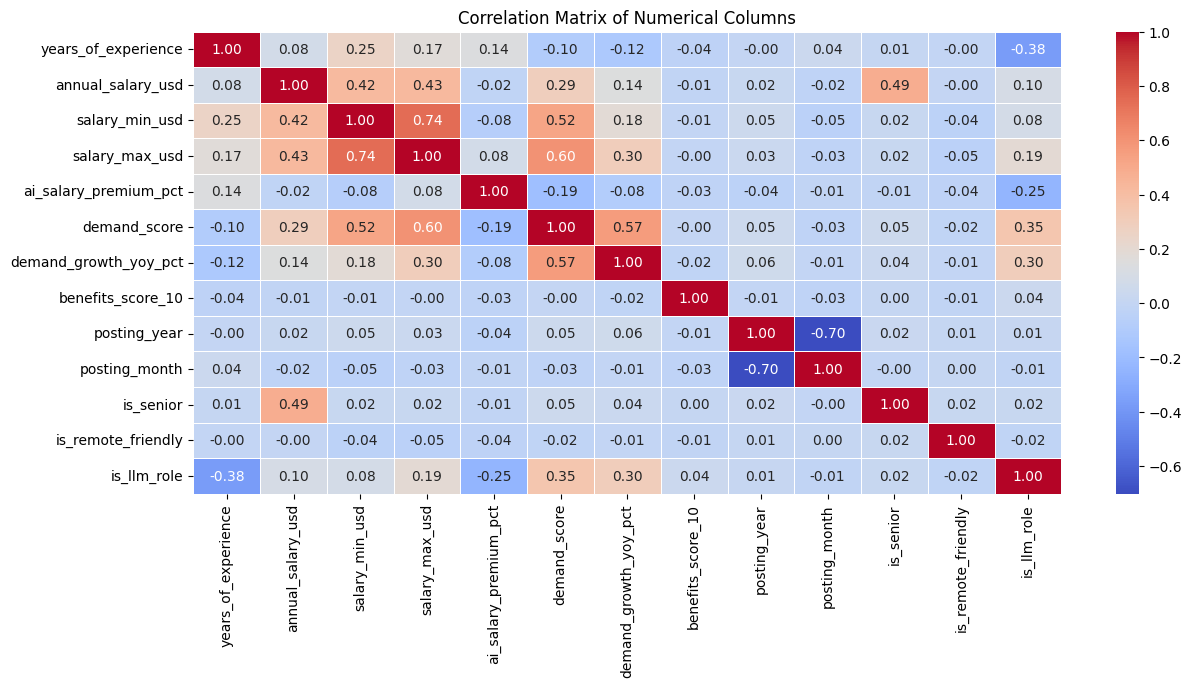

In [10]:
corr_matrix = Num_cols.corr()

plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()

In [11]:
Num_cols.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   years_of_experience    1500 non-null   int64  
 1   annual_salary_usd      1500 non-null   float64
 2   salary_min_usd         1500 non-null   int64  
 3   salary_max_usd         1500 non-null   int64  
 4   ai_salary_premium_pct  1500 non-null   float64
 5   demand_score           1500 non-null   int64  
 6   demand_growth_yoy_pct  1500 non-null   float64
 7   benefits_score_10      1500 non-null   float64
 8   posting_year           1500 non-null   int64  
 9   posting_month          1500 non-null   int64  
 10  is_senior              1500 non-null   int64  
 11  is_remote_friendly     1500 non-null   int64  
 12  is_llm_role            1500 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 152.5 KB


In [14]:
N_data = data[[
    'years_of_experience',
    'ai_salary_premium_pct',
    'demand_score',
    'demand_growth_yoy_pct',
    'benefits_score_10',
    'is_senior',
    'is_remote_friendly',
    'is_llm_role',
    'job_title',
    'job_category',
    'experience_level',
    'education_required',
    'city',
    'country',
    'remote_work',
    'company_size',
    'industry'
]].copy()

print("Final features stored in N_df for model:")
print(N_data)

Final features stored in N_df for model:
      years_of_experience  ai_salary_premium_pct  demand_score  \
0                       7                   13.1            96   
1                       2                    5.4            82   
2                       4                    9.1            98   
3                       3                   12.0            88   
4                       5                    9.4            85   
...                   ...                    ...           ...   
1495                    8                    8.8            90   
1496                    9                    6.7            91   
1497                   10                   10.9            68   
1498                    4                    8.5            91   
1499                    5                   12.2            80   

      demand_growth_yoy_pct  benefits_score_10  is_senior  is_remote_friendly  \
0                      16.9                6.8          1                   0   
1   